In [1]:
import glob
from func import *
import pandas as pd
import csv
import numpy as np
from statsmodels.sandbox.stats.multicomp import multipletests
import sys 
sys.path.append("..") 
from utils import *
# from scripts import process_ptb, process_ctb
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 15
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['savefig.dpi'] = 300 
plt.rcParams['figure.dpi'] = 300 


# Treebank: Response Process
If you obtain the annotations from treebanks, you can process the raw data by the scripts in this section.

Or you can replicate our results by using our processed data, which can be directly used in the **Treebank: visualization** section.

## ChatGPT

In [ ]:
def compute_explained_ratio(total_phrase):

    total_test_node_type = []
    total_test_parent_type = []
    
    for phrase_sent in total_phrase:
        node_type_lst = []
        parent_type_lst = []
        for item in phrase_sent:
            demon = item[-1]
        
            demon_feature = cons_feature_dict[demon]
            demon_tok = label_dict[demon][1]
            demon_label_cons = get_label_cons(demon_tok, demon_feature)
            demon_node = demon_label_cons.split('-')[0]
            demon_parent = demon_feature[-2][demon_label_cons][-1].split('-')[0]
    
            cons_feature = cons_feature_dict[item[0]]
            for test_label_cons in item[2]:
                node_type_lst.append([demon_node, test_label_cons.split('-')[0], ])
                parent_type_lst.append([demon_parent, cons_feature[-2][test_label_cons][-1].split('-')[0]])

        total_test_node_type.append(node_type_lst)
        total_test_parent_type.append(parent_type_lst)
    return total_test_node_type, total_test_parent_type


result_lst = []
for lang in ['english', 'chinese']:
    total_result = []
    paths = glob.glob(f"result/treebank/{lang}/chatgpt/*.csv")
    for p in paths:
        result = []
        resp_file = pd.read_csv(p,
                        delimiter='\t',
                        quoting=csv.QUOTE_NONE,
                        quotechar=None,)
        for idx, row in resp_file.iterrows():
            result.append(row.tolist())
        total_result.append(result)
    result_lst.append(total_result)

# constituent rate
res_lst = []
for idx, lang in enumerate(['english', 'chinese']):
    if 'lang' == 'chinese':
        label_dict = load_label_dict('chinese')
        cons_feature_dict = read_pkl('data/ctb_cons_feature.pkl')
    else:
        label_dict = load_label_dict('english')
        cons_feature_dict = read_pkl('data/ptb_cons_feature.pkl')
    total_result = result_lst[idx]
    model_type = 'GPT-3.5-turbo-azure'
    total_phrase = []
    total_word = []
    total_char = []
    total_fail = []
    total_sent = []
    for result in total_result:

        # print(len(vp_result), len(xp_result))
        # print(result)
        if lang == 'chinese':
            phrase_sent, word_sent, char_sent, fail_sent = process_ctb.ctb_constituent_analysis(result, cons_feature_dict)
            total_char.append(char_sent)
        else:
            phrase_sent, mixed_sent, word_sent, fail_sent = process_ptb.ptb_constituent_analysis(result, cons_feature_dict)
            total_char.append(mixed_sent)
            assert len(mixed_sent) == 0
        total_sent.append(result)
        total_phrase.append(phrase_sent)
        total_word.append(word_sent)
        total_fail.append(fail_sent)
    phrase_level_lst = []
    word_level_lst = []
    char_level_lst = []
    fail_rate_lst = []
    
    for result, phrase_sent, \
        word_sent, char_sent, fail_sent in zip(total_sent, total_phrase, 
                                               total_word, total_char, total_fail):

        phrase_level_lst.append(len(phrase_sent) / len(result))
        word_level_lst.append(len(word_sent) / len(result))
        char_level_lst.append(len(char_sent) / len(result))
        fail_rate_lst.append(len(fail_sent) / len(result))
        
    res_lst.append([phrase_level_lst, word_level_lst, fail_rate_lst, char_level_lst])
cons_rate = res_lst

# explained ratio
model_plot_lst = []
for idx, lang in enumerate(['english', 'chinese']):
    if 'lang' == 'chinese':
        label_dict = load_label_dict('chinese')
        cons_feature_dict = read_pkl('data/ctb_cons_feature.pkl')
    else:
        label_dict = load_label_dict('english')
        cons_feature_dict = read_pkl('data/ptb_cons_feature.pkl')
        
    total_phrase = []
    total_sent = []
    total_result = result_lst[idx]
    for result in total_result:
        # print(result)
        xp_result = []
        vp_result = []
        for res in result:

            if not is_xp(cons_feature_dict[res[0]], 'VP', 'NP'):
                vp_result.append(res)
            else:
                xp_result.append(res)
        # print(len(xp_))
        # print(xp_result)
        demon_lst = [item[-1] for item in xp_result]
        xp_result = [item[:-1] for item in xp_result]
        if lang == 'chinese':
            phrase_sent, word_sent, char_sent, fail_sent = process_ctb.ctb_constituent_analysis(xp_result, cons_feature_dict, demon_lst)
        else:
            phrase_sent, mixed_sent, word_sent, fail_sent = process_ptb.ptb_constituent_analysis(xp_result, cons_feature_dict, demon_lst)
        total_sent.append(xp_result)
        total_phrase.append(phrase_sent)


    
    (total_test_node_type, 
    total_test_parent_type) = compute_explained_ratio(total_phrase)


    # for VP-XP-NP
    model_plot = [[] for _ in range(len(total_test_node_type))]
    for idx, (test_node, test_parent) in enumerate(zip(total_test_node_type, 
                                                        total_test_parent_type)):
        
        total = 0
        node_rate = 0
        parent_rate = 0
        for node, parent in zip(test_node, test_parent):
            # print(node)

            if node[0] == node[1] and parent[0] == parent[1]:
                continue
            if node[0] == node[1]:
                node_rate += 1
            if parent[0] == parent[1]:
                parent_rate += 1
            total +=1

        node_rate = node_rate / total
        parent_rate = parent_rate/ total

        model_plot[idx].extend([ node_rate, parent_rate])
    model_plot_lst.append(model_plot)
gpt_explained_ratio = model_plot_lst

## Native speaker & L2 speaker

In [ ]:
def process_human_result(paths):
    result_lst =[]
    for p in paths:

        res_file = pd.read_csv(p,
                            delimiter='\t',
                            quoting=csv.QUOTE_NONE,
                            quotechar=None,
                            error_bad_lines=False)
        result = []
        demon = []
        for index, row in res_file.iterrows():
            orig = row['original']
            pred = row['prediction']
            if pd.isna(pred):
                result.append([orig, label_dict[orig][0], 'fail to follow'])
                demon.append(row['group'])
                continue
            pred = re.sub(r'\W', ' ', pred)
            pred = pred.split(' ')
            pred = list(filter(lambda x: x and x.strip(), pred))
            pred = ' '.join(pred)
            if orig == pred:
                pred = 'fail to follow'
            if not set(pred.lower().split(' ')).issubset(set(orig.lower().split(' '))) :
                pred = 'fail to follow'
            
            result.append([orig, label_dict[orig][0], pred])
            demon.append(row['group'])

        total_result = []
        for res, d in zip(result, demon):
            total_result.append(res + [d])
        result_lst.append(total_result)

    if 'chinese' in paths[0]:
        cons_feature_dict = read_pkl('data/ctb_cons_feature.pkl')
        label_dict = load_label_dict('chinese')
    else:
        cons_feature_dict = read_pkl('data/ptb_cons_feature.pkl')
        label_dict = load_label_dict('english')
    constituent_rate = []
    for result in result_lst:
        demon = [item[-1] for item in result]
        result = [item[:-1] for item in result]
        if 'ctb' in paths[0]:
            phrase_sent, word_sent, char_sent, fail_sent = process_ctb.ctb_constituent_analysis(result, cons_feature_dict)
            constituent_rate.append([len(phrase_sent) / len(result),
                            len(word_sent) / len(result),
                            len(fail_sent) / len(result),
                            len(char_sent) / len(result)])
        else:
            phrase_sent, mixed_sent, word_sent, fail_sent = process_ptb.ptb_constituent_analysis(result, cons_feature_dict, demon)

            constituent_rate.append([len(phrase_sent) / len(result),
                            len(word_sent) / len(result),
                            len(fail_sent) / len(result)])
    
    syntactic_category = []
    for result in result_lst:
        node_type = []
        parent_type = []
        demon = [item[-1] for item in result]
        result = [item[:-1] for item in result]
        if 'chinese' in paths[0]:
            phrase_sent, word_sent, char_sent, fail_sent = process_ctb.ctb_constituent_analysis(result, cons_feature_dict, demon)
        else:
            phrase_sent, mixed_sent, word_sent, fail_sent = process_ptb.ptb_constituent_analysis(result, cons_feature_dict, demon)
        for phrase_item in phrase_sent:

            demon_feature = cons_feature_dict[phrase_item[-1]]
            demon_cons = label_dict[phrase_item[-1]][2]
            demon_node = demon_cons.split('-')[0]
            demon_parent = demon_feature[-2][demon_cons][-1].split('-')[0]

            cons_feature = cons_feature_dict[phrase_item[0]]
            for cons in phrase_item[2]:
                test_node = cons.split('-')[0]
                test_parent = cons_feature[-2][cons][-1].split('-')[0]
                node_type.append([demon_node, test_node])
                parent_type.append([demon_parent, test_parent])

        syntactic_category.append([node_type, parent_type])
    explained_ratio = []
    for subj in syntactic_category:

        node_rate = 0
        parent_rate = 0
        total = 0
        for node, parent in zip(subj[0], subj[1]):
            if node[0] == node[1] and parent[0] == parent[1]:
                continue

            if node[0] == node[1]:
                node_rate += 1
            if parent[0] == parent[1]:
                parent_rate += 1
            total += 1
        if total == 0:
            continue
        explained_ratio.append([node_rate / total, parent_rate / total])
    return constituent_rate, explained_ratio
en_native_paths = glob.glob('result/treebank/english/native/*.csv')
en_l2_paths = glob.glob('result/treebank/english/l2/*.csv')
zh_native_paths = glob.glob('result/treebank/chinese/native/*.csv')

en_native_constituent_rate, en_native_explained_ratio = process_human_result(en_native_paths)
en_l2_constituent_rate, en_l2_explained_ratio = process_human_result(en_l2_paths)
zh_native_constituent_rate, zh_native_explained_ratio = process_human_result(zh_native_paths)


# Treebank: Visualization

## Constituent rate

/tmp/ipykernel_370010/3328537729.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g = sns.barplot(data = df, x='class', y='value', hue='type', ax=ax,


[3 3 3 3]


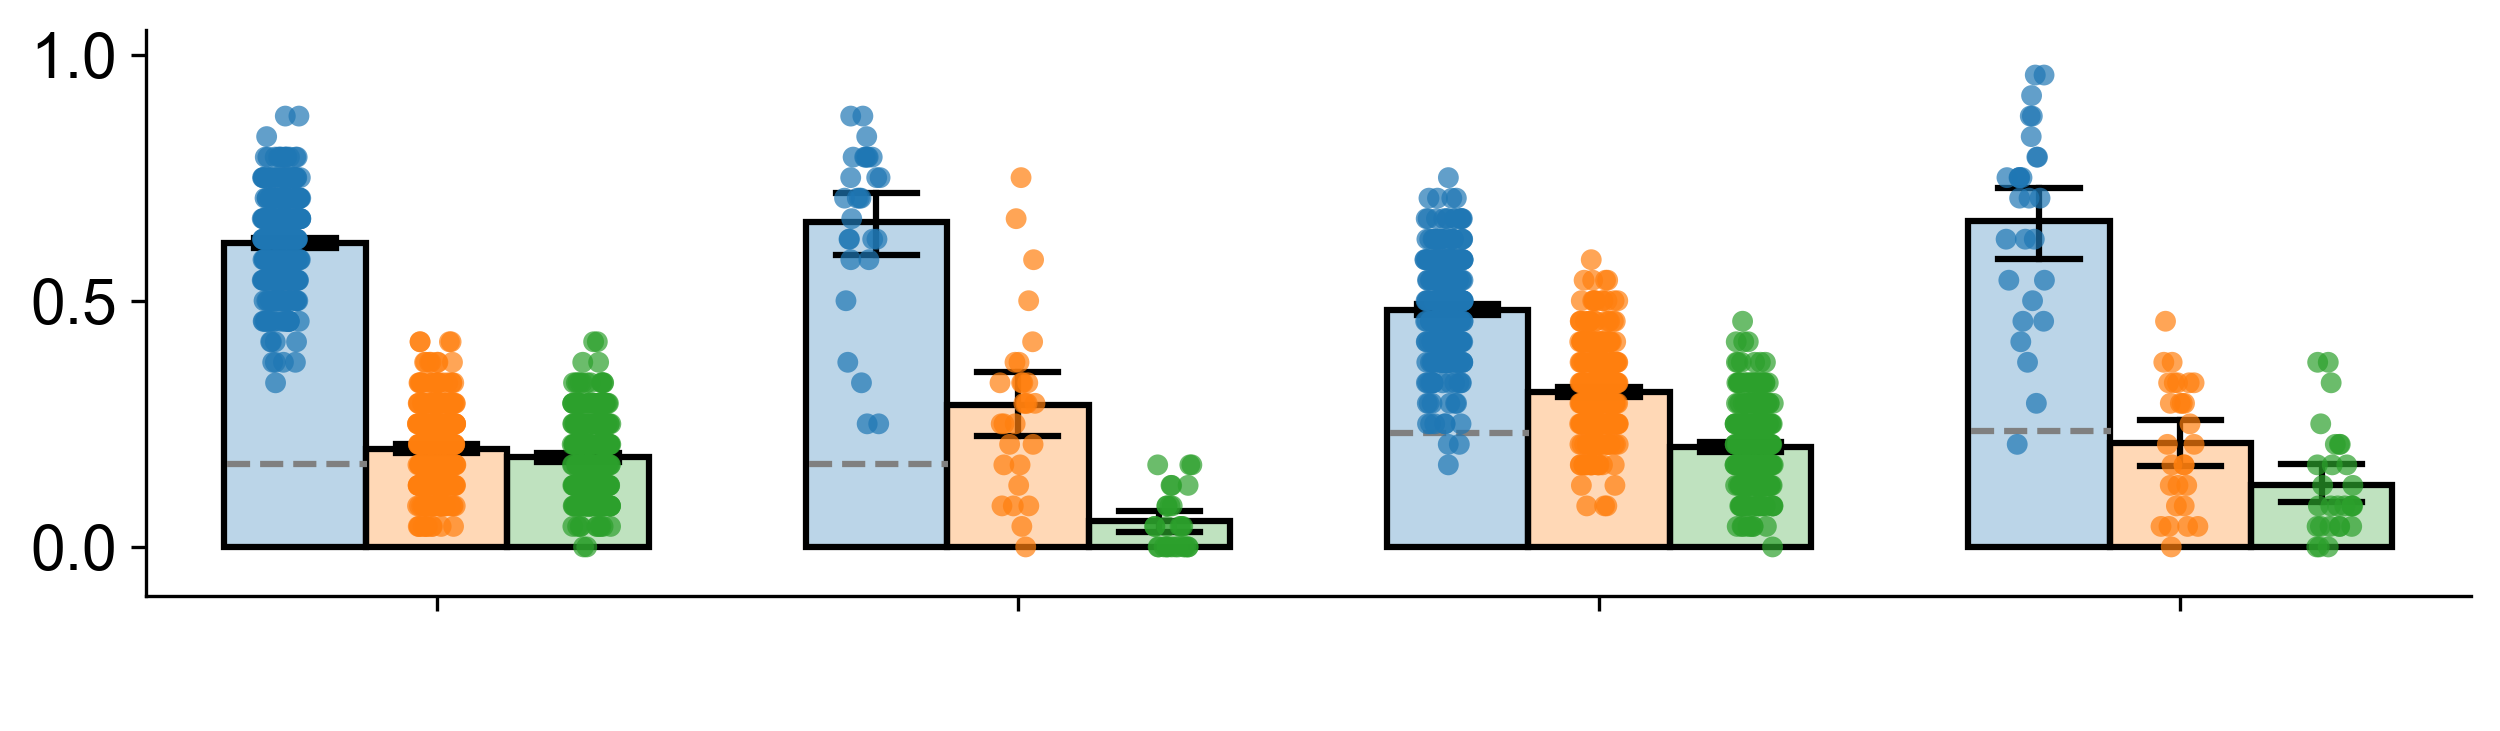

In [2]:
plt.rcParams['font.size'] = 15

processed_data = read_pkl('processed_data/constituent_rate.pkl')
df = processed_data[0]
chance = processed_data[1]
fig, ax = plt.subplots(1, 1 , figsize=(10,2.5))
sns.set_context(rc = {'patch.linewidth': 1.5})

df = pd.DataFrame.from_dict(df)
df_vpnp_phrase = df


palette = {
    'phrase': '#1f77b4',
    'word': '#ff7f0e',
    'fail': '#2ca02c'
}


g = sns.barplot(data = df, x='class', y='value', hue='type', ax=ax, 
                palette=palette,
                errorbar = ('ci', 95),  
                estimator=np.mean, ci=95, capsize=.14, 
                errwidth=1.5, errcolor = 'k', 
                edgecolor =  (0,0,0,1), width=0.73
                )
hue_nums = df.groupby("class")["type"].nunique().values
print(hue_nums)

color_lst = ['#1f77b4',
    '#ff7f0e',
    
    '#2ca02c',
    '#d62728',]


for i, bar in enumerate(g.patches):
    x_category = np.repeat(np.arange(len(hue_nums)), len(hue_nums))[i]
    hue_category = np.tile(np.arange(max(hue_nums)), len(hue_nums))[i]
    color = color_lst[x_category]
    bar.set_facecolor(to_rgba(color, 0.3))
    bar.set_edgecolor((0, 0, 0, 1))
    
ax.axhline(y=np.mean(chance[0]), xmin=0.035, xmax=0.095,ls='--',c='grey')
ax.axhline(y=np.mean(chance[1]), xmin=0.285, xmax=0.345,ls='--',c='grey')

ax.axhline(y=np.mean(chance[2]), xmin=0.535, xmax=0.595,ls='--',c='grey')
ax.axhline(y=np.mean(chance[3]), xmin=0.785, xmax=0.845,ls='--',c='grey')
g = sns.stripplot(
    data = df,
    x="class", 
    y="value", 
    hue="type", 
    dodge=True, 
    alpha=0.7,
    edgecolor=None, 
    ax=ax
)

plt.ylim([-0.0,1.05])
sns.despine(top=True, right=True, left=False, bottom=False)
g.set(ylabel='')
g.set(xlabel='  ')

g.set(ylim=[-0.1,1.05])
g.set(ylabel='Proportion')
g.set(xlabel='  ')
g.set(xticklabels=[])

hatches = ['', '', '', '']*3

for i,thisbar in enumerate(g.patches):
    thisbar.set_hatch(hatches[i])

plt.ylabel("")
plt.xlabel(r"   ")

plt.legend([],[], frameon=False)


## constituent rate of LSTM

/tmp/ipykernel_370010/2094900305.py:19: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  g.set(xlim=[0,900])
/tmp/ipykernel_370010/2094900305.py:34: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  g.set(xlim=[0,900])


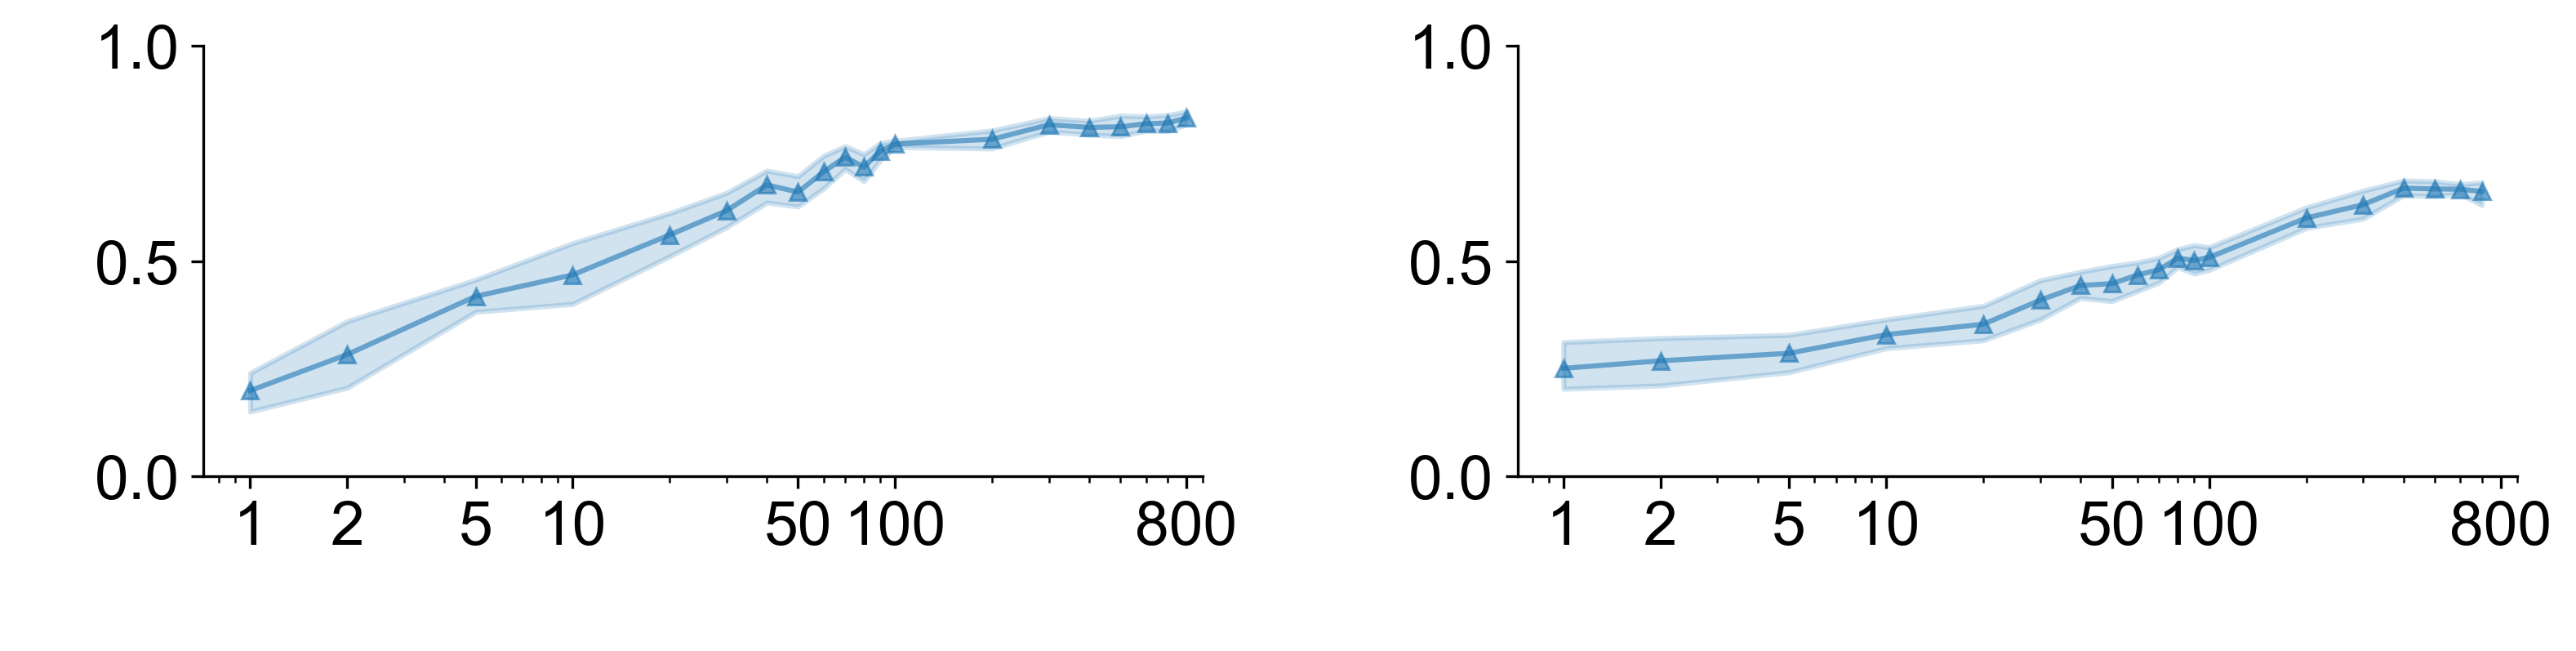

In [3]:
plt.rcParams['font.size'] = 18

fig, axes = plt.subplots(1, 2,figsize=(11,3))
sns.despine(top=True, right=True, left=False, bottom=False)

df = read_pkl('processed_data/constituent_rate_lstm.pkl')

data = df[df['lang'] == 'en']
g = sns.lineplot(x="n_sample", y="phrase", data=data, 
                 marker="^", errorbar=('ci', 95),
                markersize=5, markeredgecolor=None, ax=axes[0], alpha=0.6,
                )


g.set(xscale='log')
g.set(xticks=[1,2,5,10,50,100,800])
g.set(xticklabels=[1,2,5,10,50,100,800])
g.set(ylim=(0,1))
g.set(xlim=[0,900])
g.set(xlabel='  ')
g.set(ylabel='  ')
axes[0].legend([],[], frameon=False)

data = df[df['lang'] == 'zh']
g = sns.lineplot(x="n_sample", y="phrase", data=data, 
                 marker="^", errorbar=('ci', 95),
                markersize=5, markeredgecolor=None, ax=axes[1], alpha=0.6,
                )

g.set(xscale='log')
g.set(xticks=[1,2,5,10,50,100,800])
g.set(xticklabels=[1,2,5,10,50,100,800])
g.set(ylim=(0,1))
g.set(xlim=[0,900])
g.set(xlabel='  ')
g.set(ylabel='  ')
axes[1].legend([],[], frameon=False)
plt.tight_layout()

## Explained ratio

model-en significance test, original:  0.00019998000199980003 FDR corrected:  0.00026664000266640004
human-en significance test, original:  0.00019998000199980003 FDR corrected:  0.00026664000266640004
model-zh significance test, original:  0.00019998000199980003 FDR corrected:  0.00026664000266640004
human-zh significance test, original:  0.00039996000399960006 FDR corrected:  0.00039996000399960006


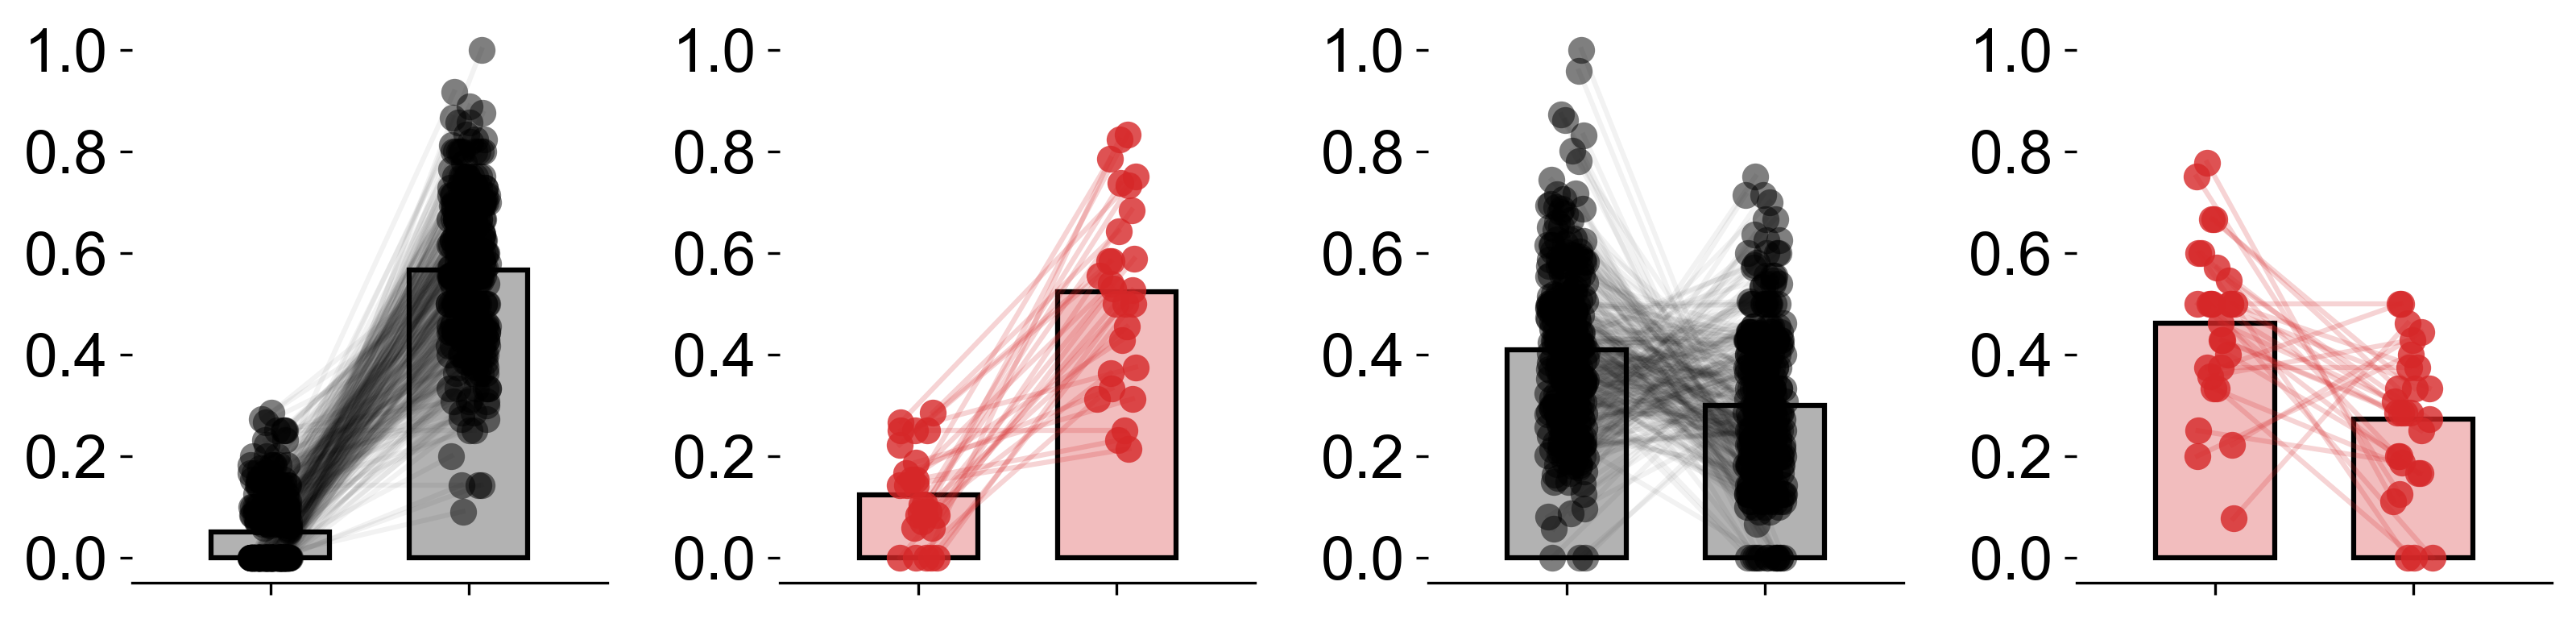

In [4]:

fig, axes = plt.subplots(1,4, figsize=(11,2.9))
sns.despine(top=True, right=True, left=True, bottom=False)
pvals =[]
sns.set_context(rc = {'patch.linewidth': 1.5})
df = read_pkl('processed_data/explained_ratio.pkl')
model_lst = ['model-en', 'human-en', 'model-zh', 'human-zh']
for idx, (ax, prefix) in enumerate(zip(axes, model_lst,)):
    plot_df = df[df.iloc[:,0].str.contains(prefix + '_')]
    palette = {
        'model-en': 'k',
        'model-zh': 'k',
        'human-en': '#d62728',
        'human-zh': '#d62728',
    }

    color = palette[prefix]

    g = sns.barplot(data = plot_df, x='subj', y='value', ax=ax, 
                    color=color,
                    errorbar = None,  
                    capsize=.1, 
                    width=0.6,
                    edgecolor = (0,0,0,1),
                    )
    for i, bar in enumerate(g.patches):
        color = color
        bar.set_facecolor(to_rgba(color, 0.3))
        bar.set_edgecolor((0, 0, 0, 1))
    if 'model' in prefix:
        alpha = 0.5
    else:
        alpha=0.8
    g = sns.stripplot(data=plot_df, x='subj', y='value', ax=ax, 
                      size=8, color=color, edgecolors='k', alpha=alpha)

    a = ax.scatter([1,2],[3,4], marker='o')
    b = ax.scatter([1,2],[3,4], marker='o')

    square_mk, = a.get_paths()
    triangle_up_mk, = b.get_paths()
    a.remove()
    b.remove()
    N_hues = len(pd.unique(plot_df.subj))

    c = ax.collections
    for a in c[::N_hues]:
        a.set_paths([triangle_up_mk])
    for a in c[1::N_hues]:
        a.set_paths([square_mk])
    #update legend
    ax.legend(c[-2:],pd.unique(plot_df.subj))


    set1 = plot_df[plot_df['subj'] == prefix+'_node']['value'].tolist()
    set2 = plot_df[plot_df['subj'] == prefix+'_parent']['value'].tolist()
    pvals.append([prefix, paired_bootstrap_test(set1, set2)])


    idx0 = 2
    idx1 = 3
    locs1 = ax.get_children()[idx0].get_offsets()
    locs2 = ax.get_children()[idx1].get_offsets()


    sort_idxs1 = np.argsort(set1)
    sort_idxs2 = np.argsort(set2)


    locs2_sorted = locs2[sort_idxs2.argsort()][sort_idxs1]
    locs2_sorted = locs2
    if 'model' in prefix:
        alpha = 0.05
    else:
        alpha=0.2
    for i in range(locs1.shape[0]):
        x = [locs1[i, 0], locs2_sorted[i, 0]]
        y = [locs1[i, 1], locs2_sorted[i, 1]]
        ax.plot(x, y, color=color, alpha=alpha)
    g.set(xlim=[-0.7,1.7])
    g.set(ylim=[-0.05, 1.05])
    g.set(yticks=[0,0.2,0.4,0.6,0.8,1.0])
    g.set(ylabel='')
    g.set(xlabel='')
    g.set(xticklabels='')

    ax.legend([],[], frameon=False)
plt.tight_layout()

reject, pvals_corrected, _, _ = multipletests([p[1] for p in pvals], alpha=0.05, method='fdr_bh')
for p, corrected_p in zip(pvals, pvals_corrected):
    print(p[0], 'significance test, original: ', p[1], 'FDR corrected: ', corrected_p)



# Parallel: response process
The results of parallel sentences can be directly processed, without annotations of treebanks.

But you can also replicate our results by using our processed data, which can be directly used in the **Parallel: visualization** section.

In [ ]:

parsed_file = pd.read_csv('stimulus/parallel/constituency_tree.csv',
            delimiter='\t',
            quoting=csv.QUOTE_NONE,
            quotechar=None)
sentence = parsed_file['sentence'].values.tolist()
parsed = parsed_file['tree'].values.tolist()
en_parsed_lst = []
zh_parsed_lst = []
for sent, tree in zip(sentence, parsed):
    if len(re.findall('[^\u4e00-\u9fa5]', sent)) != 0:
        en_parsed_lst.append([sent, tree])
    else:
        zh_parsed_lst.append([sent, tree])
en_cons_feature_dict, _ = process_ptb.get_cons_feature(en_parsed_lst)
cons_feature_dict, _ = process_ctb.get_cons_feature(zh_parsed_lst)
cons_feature_dict.update(en_cons_feature_dict)

## ChatGPT

In [ ]:
# English

total_result_en = []
paths = glob.glob(f"result/parallel/english/chatgpt/*.csv")
for p in paths:
    result = []
    resp_file = pd.read_csv(p,
                    delimiter='\t',
                    quoting=csv.QUOTE_NONE,
                    quotechar=None,)
    for idx, row in resp_file.iterrows():
        result.append(row.tolist())
    total_result_en.append(result)


# Chinese

total_result_zh = []
paths = glob.glob(f"result/parallel/chinese/chatgpt/*.csv")
for p in paths:
    result = []
    resp_file = pd.read_csv(p,
                    delimiter='\t',
                    quoting=csv.QUOTE_NONE,
                    quotechar=None,)
    for idx, row in resp_file.iterrows():
        result.append(row.tolist())
    total_result_zh.append(result)

total_phrase = []
for result in total_result_en:
    
    phrase_sent, mixed_sent, word_sent, fail_sent = process_ptb.ptb_constituent_analysis(result, cons_feature_dict)
    total_phrase.append(phrase_sent)

for result in total_result_zh:
    phrase_sent, word_sent, char_sent, fail_sent = process_ctb.ctb_constituent_analysis(result, cons_feature_dict)
    total_phrase.append(phrase_sent)
    


# 删除item的结点类型
total_node = []

# 删除item的父节点类型
total_parent = []

for phrase_sent in total_phrase:
    node_lst = []
    parent_lst = []

    for phrase_item in phrase_sent:
        if ' ' in phrase_item[0]:
            if len(phrase_item[0].split(' ')) - len(phrase_item[1].split(' ')) == 1:
                continue
        else:
            if len(list(phrase_item[0])) - len(list(phrase_item[1])) == 1:
                continue
        cons_feature = cons_feature_dict[phrase_item[0]]
        for test_label_cons in phrase_item[2]:
            node = test_label_cons.split('-')[0]
            parent = cons_feature[5][test_label_cons][-1].split('-')[0]
            node_lst.append(node)
            parent_lst.append(parent)
    total_node.append(node_lst)
    total_parent.append(parent_lst)

node_explained = []
parent_explained = []
for node_lst, parent_lst in zip(total_node, total_parent):
    node_rate = 0
    parent_rate = 0
    for node, parent in zip(node_lst, parent_lst):
        if node == 'NP' and parent == 'VP':
            continue
        if node == 'NP':
            node_rate+=1
        if parent == 'VP':
            parent_rate += 1
    node_explained.append(node_rate / len(node_lst))
    parent_explained.append(parent_rate / len(parent_lst))




## Human

In [ ]:
def process_human_result(paths):
    total_result_lst = []
    for p in paths:
        res_file = pd.read_csv(p,
                            delimiter='\t',
                            quoting=csv.QUOTE_NONE,
                            quotechar=None)
        result = []
        for index, row in res_file.iterrows():
            orig = row['original']
            pred = row['prediction']
            if pd.isna(pred):
                result.append([orig, 'fail to follow', row['demonstration']])
                continue
            pred = re.sub(r'\W', ' ', pred)
            pred = pred.split(' ')
            pred = list(filter(lambda x: x and x.strip(), pred))
            pred = ' '.join(pred)
            if not set(list(pred.lower().split(' '))).issubset(set(list(orig.lower().split( )))) :
                pred = 'fail to follow'
            elif pred == orig:
                pred = 'fail to follow'
            result.append([orig, pred, row['demonstration']])
        total_result_lst.append(result)
    return total_result_lst

def load_subj_explained(result_lst, subj_type, cons_feature_dict):

    inter_subj = []
    for result in result_lst:
        node_type = []
        parent_type = []
        demon = [item[-1] for item in result]
        result = [item[:-1] for item in result]
        if 'zh' in subj_type:
            phrase_sent, word_sent, char_sent, fail_sent = process_ctb.ctb_constituent_analysis(result, cons_feature_dict)
        else:
            phrase_sent, mixed_sent, word_sent, fail_sent = process_ptb.ptb_constituent_analysis(result, cons_feature_dict, demon)

        for phrase_item in phrase_sent:
            cons_feature = cons_feature_dict[phrase_item[0]]
            for cons in phrase_item[2]:
                test_node = cons.split('-')[0]
                test_parent = cons_feature[-2][cons][-1].split('-')[0]
                node_type.append(['NP', test_node])
                parent_type.append(['VP', test_parent])

        inter_subj.append([node_type, parent_type])
    plot_data = []
    for subj in inter_subj:
        if len(subj[0]) ==0:
            continue 
        node_rate = 0
        parent_rate = 0
        total = 0
        for node, parent in zip(subj[0], subj[1]):
            # print(node)
            if node[0] == node[1] and parent[0] == parent[1]:
                continue
            if node[0] == node[1]:
                node_rate += 1
            if parent[0] == parent[1]:
                parent_rate += 1

            total += 1
        if total == 0:
            continue

        plot_data.append([node_rate / total, parent_rate / total])
    return plot_data


zh_paths = glob.glob('result/parallel/chinese/native/*.csv')
en_paths = glob.glob('result/parallel/english/l2/*.csv')
zh_result = process_human_result(zh_paths)
en_result = process_human_result(en_paths)
zh_explained = load_subj_explained(zh_result, 'zh', cons_feature_dict)
en_explained = load_subj_explained(en_result, 'en', cons_feature_dict)


# Parallel: visualization

model-en significance test, original:  0.00019998000199980003 FDR corrected:  0.00026664000266640004
human-en significance test, original:  0.00019998000199980003 FDR corrected:  0.00026664000266640004
model-zh significance test, original:  0.00019998000199980003 FDR corrected:  0.00026664000266640004
human-zh significance test, original:  0.0035996400359964 FDR corrected:  0.0035996400359964


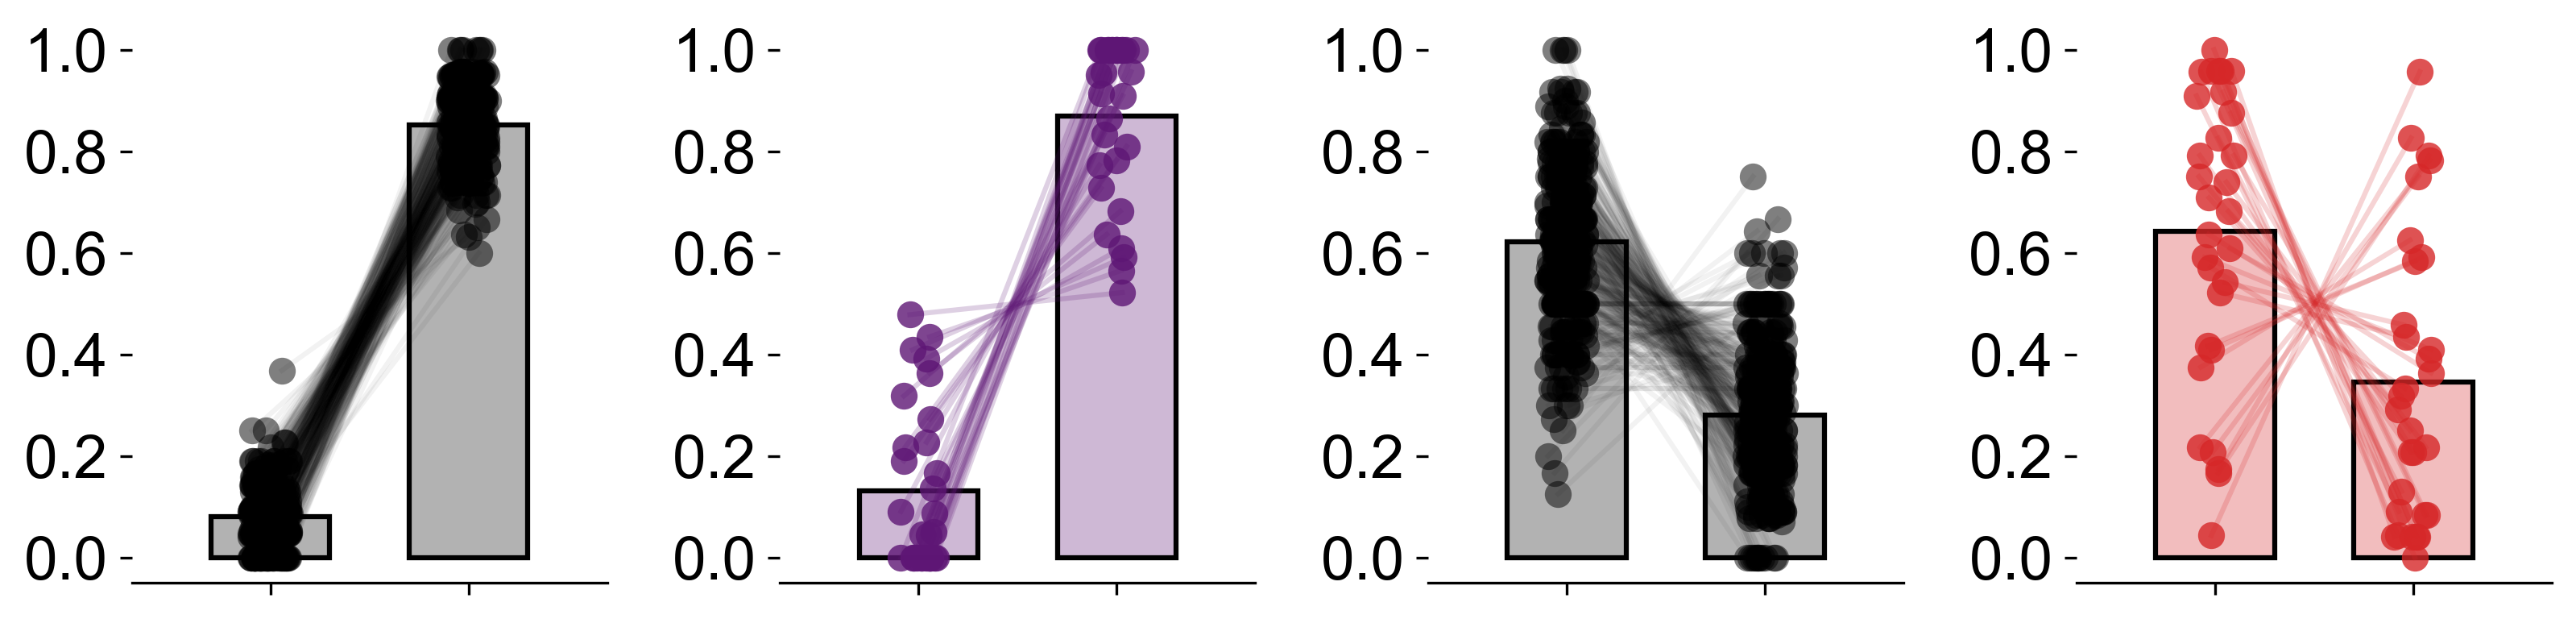

In [5]:
df = read_pkl('processed_data/explained_ratio_parallel.pkl')

fig, axes = plt.subplots(1,4, figsize=(11,2.9))
sns.despine(top=True, right=True, left=True, bottom=False)
sns.set_context(rc = {'patch.linewidth': 1.5})
model_lst = ['model-en', 'human-en', 'model-zh', 'human-zh']
pvals = []
for idx, (ax, prefix) in enumerate(zip(axes, model_lst,)):
    plot_df = df[df.iloc[:,0].str.contains(prefix + '_')]
    palette = {

        'model-en': 'k',
        'model-zh': 'k',
        'human-en': '#5E1675',
        'human-zh': '#d62728',
    }

    color = palette[prefix]
    g = sns.barplot(data = plot_df, x='subj', y='value', ax=ax, 
                    color=color,
                    errorbar = None,  
                    capsize=.1, 
                    width=0.6,
                    edgecolor = (0,0,0,1),
                    )
    for i, bar in enumerate(g.patches):
        color = color
        bar.set_facecolor(to_rgba(color, 0.3))
        bar.set_edgecolor((0, 0, 0, 1))
    if 'model' in prefix:
        alpha = 0.5
    else:
        alpha=0.8
    g = sns.stripplot(data=plot_df, x='subj', y='value', ax=ax, 
                      size=8, color=color, edgecolors='k', alpha=alpha)
    if idx < 2:
        a = ax.scatter([1,2],[3,4], marker='o')
        b = ax.scatter([1,2],[3,4], marker='o')
    else:
        a = ax.scatter([1,2],[3,4], marker='o')
        b = ax.scatter([1,2],[3,4], marker='o')
    square_mk, = a.get_paths()
    triangle_up_mk, = b.get_paths()
    a.remove()
    b.remove()
    N_hues = len(pd.unique(plot_df.subj))

    c = ax.collections
    for a in c[::N_hues]:
        a.set_paths([triangle_up_mk])
    for a in c[1::N_hues]:
        a.set_paths([square_mk])
    #update legend
    ax.legend(c[-2:],pd.unique(plot_df.subj))


    set1 = plot_df[plot_df['subj'] == prefix+'_node']['value'].tolist()
    set2 = plot_df[plot_df['subj'] == prefix+'_parent']['value'].tolist()
    pvals.append([prefix, paired_bootstrap_test(set1, set2)])

    idx0 = 2
    idx1 = 3
    locs1 = ax.get_children()[idx0].get_offsets()
    locs2 = ax.get_children()[idx1].get_offsets()

    sort_idxs1 = np.argsort(set1)
    sort_idxs2 = np.argsort(set2)

    locs2_sorted = locs2[sort_idxs2.argsort()][sort_idxs1]
    locs2_sorted = locs2
    if 'model' in prefix:
        alpha = 0.05
    else:
        alpha=0.2
    for i in range(locs1.shape[0]):
        x = [locs1[i, 0], locs2_sorted[i, 0]]
        y = [locs1[i, 1], locs2_sorted[i, 1]]
        ax.plot(x, y, color=color, alpha=alpha)
    g.set(xlim=[-0.7,1.7])
    g.set(ylim=[-0.05, 1.05])
    # g.set(ylim=[0.1, 1.05])
    g.set(yticks=[0,0.2,0.4,0.6,0.8,1.0])
    g.set(ylabel='')
    g.set(xlabel='')
    g.set(xticklabels='')

    ax.legend([],[], frameon=False)
plt.tight_layout()

reject, pvals_corrected, _, _ = multipletests([p[1] for p in pvals], alpha=0.05, method='fdr_bh')
for p, corrected_p in zip(pvals, pvals_corrected):
    print(p[0], 'significance test, original: ', p[1], 'FDR corrected: ', corrected_p)
